# Projeto de previsão de sobreviventes do Titanic

O projeto utiliza-se da base de dados do [Kaggle](https://www.kaggle.com/competitions/titanic/overview) e visa criar um modelo preditivo que, a partir da característica fornecida das pessoas, deverá prever se a mesma iria sobreviver ou não ao acidente envolvendo o navio Titanic.

A base de dados contém dos seguintes componentes:

- `PassangerID` - Coluna do tipo *int* que indica a posição no index;
- `Survived` - coluna do tipo *int*, é uma coluna dummy, ou seja, classificado em 2 categorias: 1 para indicar que sobreviveu e 0 para indicar que não sobreviveu;
- `Pclass` - coluna do tipo *int*, que indica a classe da passagem comprada, podendo ser categorizada em: 1 para 1º classe (mais cara), 2 para 2º classe e 3 para a 3º classe (mais barata);
- `Name` - coluna do tipo *String* que identifica o nome do passageiro;
- `Sex` - coluna do tipo *String* que identifica o sexo atribuído ao nascimento;
- `Age` - coluna do tipo *float* que identifica a idade;
- `SibSp` - coluna do tipo *int*, que indica a quantidade de cônjuge e/ou irmãos presentes no navio;
- `Parch` - coluna do tipo *int*, que indica a quantidade de pais e/ou filhos presentes no navio;
- `Ticket` - coluna do tipo *String* que indica o número da passagem comprada;
- `Fare` - coluna do tipo *float* que indica o valor pago pela passagem comprada;
- `Cabin` - coluna do tipo *String* que indica o número da cabine onde o passageiro ficou alocado;
- `Embarked` coluna do tipo *String*, que indica onde o passageiro embarcou, podendo ser categorizada em: C para Cherbourg, Q para Queenstown e S para Southampton.

Importei as bibliotecas necessárias que utilizei para a execução do projeto:

Pandas para limpeza e manipulação de dados;\
Numpy para cálculos;\
Matplotlib para criar figuras de visualização de gráficos;\
Seaborn para criar gráficos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

\
A base de dados está dividida em dois arquivos, o **train.csv** para treinamento do modelo preditivo e o **test.csv** para teste da precisão do modelo. Criei um DataFrame para cada, visando a separação e deixando claro o objetivo de cada um.

In [2]:
df_train = pd.read_csv('data/train.csv')

In [3]:
df_test = pd.read_csv('data/test.csv')

\
Utilizei os métodos `head()` e `info()` do *Pandas* para comparar se os dois DataFrames possuem as mesma colunas e as mesmas tipagens de dados.

In [4]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 419 entries, 0 to 418
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  419 non-null    int64  
 1   Pclass       419 non-null    int64  
 2   Name         419 non-null    str    
 3   Sex          419 non-null    str    
 4   Age          333 non-null    float64
 5   SibSp        419 non-null    int64  
 6   Parch        419 non-null    int64  
 7   Ticket       419 non-null    str    
 8   Fare         418 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     419 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


Defini o tema das visualizações de gráficos para `whitegrid`, para que o contraste ficasse óbvio e não houvesse má interpretação das informações por um plano de fundo muito escuro ou linhas de nivelamento da coluna y não ficassem ocultas.

In [8]:
sns.set_theme(style='whitegrid')

\
Utilizei o gráfico de `mapa de calor` do *Seaborn* e o método `isnull()` do *Pandas* para verificar se existes valores nulos em ambos DataFrames, apresentando cores distintas caso haja valores nulos.

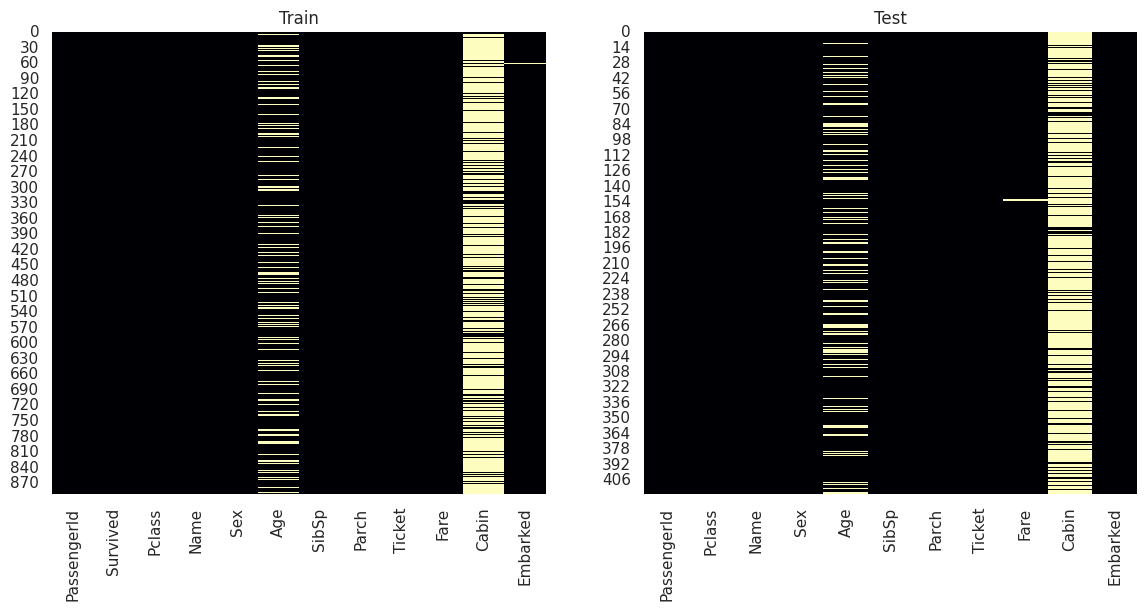

In [9]:
fig, ax = plt.subplots(1,2)
fig.set_size_inches((14,6))

fig1 = sns.heatmap(df_train.isnull(), cbar=False, cmap='magma', ax=ax[0])
fig1.set_title('Train')

fig2 = sns.heatmap(df_test.isnull(), cbar=False, cmap='magma')
fig2.set_title('Test')

plt.show()

\
Ambos DataFrames possuem diversos valores nulos nas colunas de idade e cabine, a única divergência é que o de treinamento possui um valor nulo de embarque e o de teste possui um valor nulo de tarifa.
\
\
Referente aos valores nulos de idade, o ideal é preencher com a média de idade. Para extrair tal informação, procurei por onde as idades tem uma maior classificação. Por exemplo, mediana de idade por classe, por sexo, por embarcação.

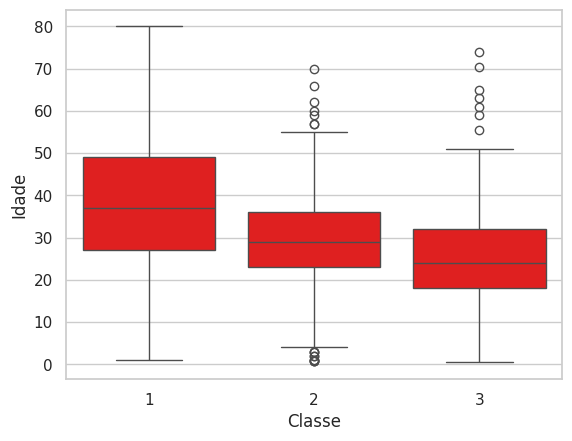

In [10]:
sns.boxplot(df_train, x='Pclass', y='Age', color='red')
plt.xlabel('Classe')
plt.ylabel('Idade')
plt.show()

\
Na visualização, podemos identificar que a mediana de idade aumenta conforme aumenta a classe da passagem. Também é possivel verificar que os outliers das classes 2 e 3 são de idades mais avançadas, ou seja, a maior frequência, nessas classes, são de pessoas mais novas.

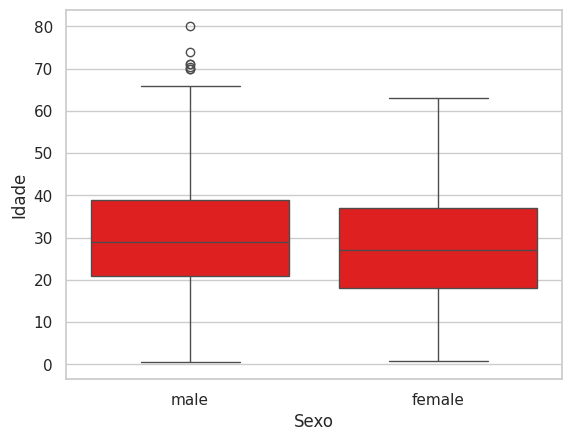

In [11]:
sns.boxplot(df_train, x='Sex', y='Age', color='Red')
plt.xlabel('Sexo')
plt.ylabel('Idade')
plt.show()

\
Já na visualização de mediana de idade por sexo, a diferença é minima, o que dificulta a extrair uma mediana precisa.

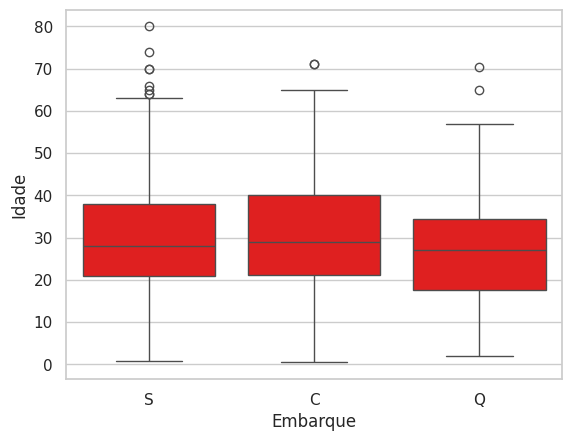

In [12]:
sns.boxplot(df_train, x='Embarked', y='Age', color='Red')
plt.xlabel('Embarque')
plt.ylabel('Idade')
plt.show()

\
Assim como na visualização de mediana de idade por sexo, a mediana por embarque apresenta valores muito próximos, assim como outliers parecidos.

\
Com a melhor classificação de mediana de idade, prossegui para criar uma função que troca as idades `null` para a mediana, conforme a classe da passagem.

In [13]:
pclass_1_age_median = df_train[df_train['Pclass'] == 1]['Age'].median()
pclass_2_age_median = df_train[df_train['Pclass'] == 2]['Age'].median()
pclass_3_age_median = df_train[df_train['Pclass'] == 3]['Age'].median()

In [14]:
def change_null_ages(columns):
    age = columns.iloc[0]
    passenger_class = columns.iloc[1]

    if np.isnan(age):
        if passenger_class == 1:
            return pclass_1_age_median
        elif passenger_class == 2:
            return pclass_2_age_median
        else:
            return pclass_3_age_median

    else:
        return age

\
Agora foi só subscrever a coluna `Age`, aplicando a função que preenche as idades nulas pela idade mediana, a partir do próprio DataFrame, enviando como paramêtro as colunas de idade e classe.

In [15]:
df_train['Age'] = df_train[['Age', 'Pclass']].apply(change_null_ages, axis=1)

In [16]:
df_test['Age'] = df_test[['Age', 'Pclass']].apply(change_null_ages, axis=1)

\
Acessei novamente o `mapa de calor` para verificar se teria algum resquício de registro nulo

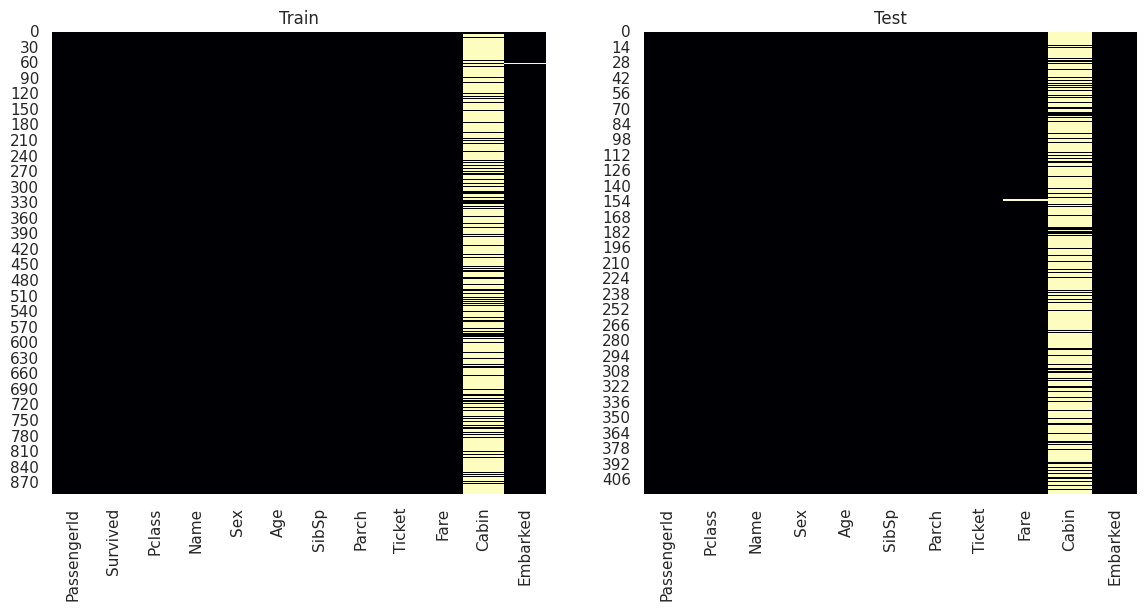

In [17]:
fig, ax = plt.subplots(1,2)
fig.set_size_inches((14,6))

fig1 = sns.heatmap(df_train.isnull(), cbar=False, cmap='magma', ax=ax[0])
fig1.set_title('Train')

fig2 = sns.heatmap(df_test.isnull(), cbar=False, cmap='magma')
fig2.set_title('Test')

plt.show()

\
Já referente aos dados nulos da coluna `Cabin`, por não ter peso na predição de sobrevivência e por apresentar na sua grande maioria dados faltantes, optei por retirar a coluna. Também optei por retirar as colunas `PassengerId`, pelo fato do DataFrame ter o seu próprio index e `Ticket` por não ter um padrão facilmente identificável.

In [18]:
df_train.drop(['Cabin','PassengerId', 'Ticket'], axis=1, inplace=True)

In [19]:
df_test.drop(['Cabin','PassengerId', 'Ticket'], axis=1, inplace=True)

In [20]:
df_train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [21]:
df_test.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,"Kelly, Mr. James",male,34.5,0,0,7.8292,Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,7.0000,S
2,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,9.6875,Q
3,3,"Wirz, Mr. Albert",male,27.0,0,0,8.6625,S
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,12.2875,S


\
Para o único dado faltante de `Embarked` e `Fare` em cada um dos DataFrames, optei por excluir o registro, pois 1 registro em meio a 800, não irá atrapalhar.

In [22]:
df_train.dropna(inplace=True)
df_train.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [23]:
df_test.dropna(inplace=True)
df_test.isnull().sum()

Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

\
Antes de ir para a manipulação dos dados, vamos fazer alguns gráficos para tirar alguns insights, como por exemplo: Sobreviveram mais ou homens ou mulheres? Qual cidade de embarque foi a que mais teve sobreviventes? Qual classe mais teve sobreviventes? Qual a idade desses sobreviventes? Existe um padrão de tudo isso?

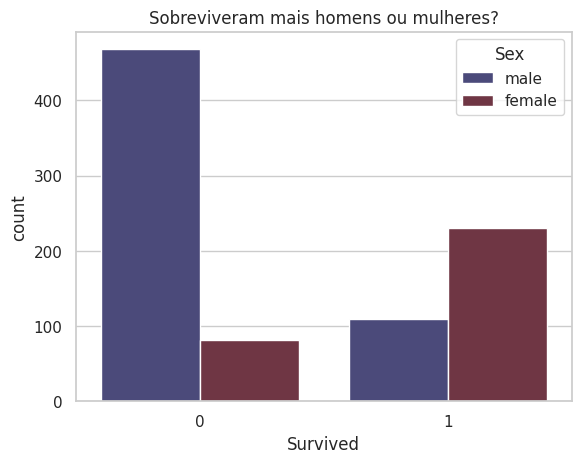

In [24]:
sns.countplot(data=df_train, x='Survived', hue='Sex', palette='icefire')
plt.title('Sobreviveram mais homens ou mulheres?')
plt.show()

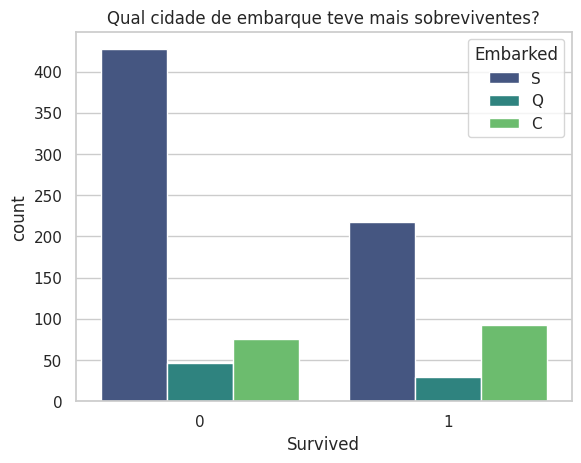

In [25]:
sns.countplot(data=df_train, x='Survived', hue='Embarked', palette='viridis')
plt.title('Qual cidade de embarque teve mais sobreviventes?')
plt.show()

Esse gráfico está estranho, a cidade *S* está com mais sobreviventes e também com mais mortes. Por isso, verifiquei a proporção, referente ao total, de quantos pessoas embarcaram em qual portão.

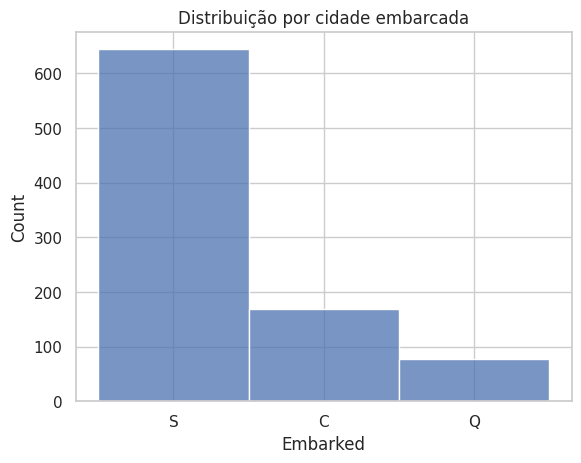

In [26]:
sns.histplot(data=df_train, x='Embarked')
plt.title('Distribuição por cidade embarcada')
plt.show()

In [27]:
df_train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [28]:
df_train['Embarked'].count()

np.int64(889)

In [29]:
print('Porcentagem de embarques na cidade S: ',(644/889) * 100)

Porcentagem de embarques na cidade S:  72.44094488188976


Agora foi possível concluir que a cidade *S* teve mais sobreviventes e não sobreviventes pois a proporção de embarque nessa cidade é mais de 72%.

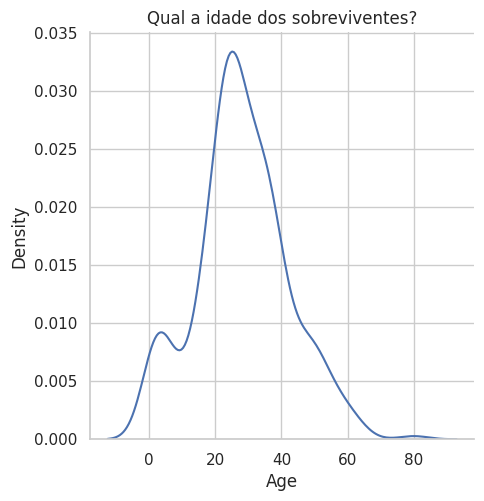

In [30]:
sns.displot(data=df_train[df_train['Survived'] == 1], x='Age', kind='kde')
plt.title('Qual a idade dos sobreviventes?')
plt.show()

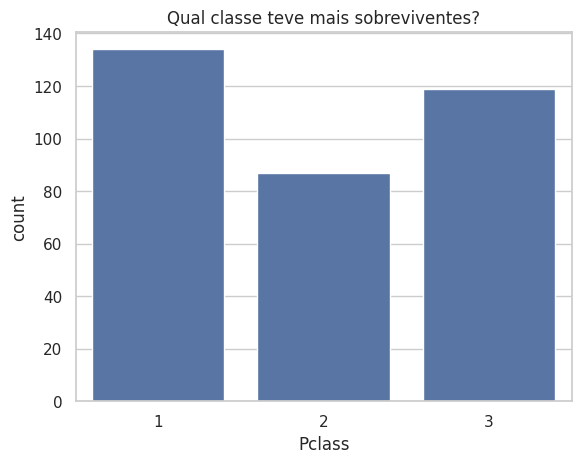

In [31]:
sns.countplot(data=df_train[df_train['Survived'] == 1], x='Pclass')
plt.title('Qual classe teve mais sobreviventes?')
plt.show()

\
Com estas informações na cabeça, hora de manipular os dados para a criação e aprendizagem do modelo preditivo.

\
Para ficar mais fácil do modelo de predição entender e interpretar as informações, alterei a coluna `Sex`, visto que os dados estavam divididos entre **male** e **female**, e os transformei em **0** e **1**, 0 sendo masculino e 1 sendo feminino.

In [32]:
sex_dict = {
    'male': 0,
    'female': 1
}

df_train = df_train.replace(sex_dict)

df_train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,S


In [33]:
df_test = df_test.replace(sex_dict)
df_test.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,"Kelly, Mr. James",0,34.5,0,0,7.8292,Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,7.0000,S
2,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,9.6875,Q
3,3,"Wirz, Mr. Albert",0,27.0,0,0,8.6625,S
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,12.2875,S


\
Para a coluna de `Embarked` segui o mesmo princípio da coluna `Sex`, porém como se tratava de 3 classificações, optei por adicionar duas colunas dummies. Os dados ficaram separados entre `Embarked_Q` e `Embarked_S`, pois se as duas colunas fossem 0, o modelo saberá que será o `Embarked_C`.

In [34]:
embark = pd.get_dummies(df_train['Embarked'], prefix='Embarked_', drop_first=True, dtype=int)
embark

,Embarked__Q,Embarked__S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1
...,...,...
886,0,1
887,0,1
888,0,1
889,0,0


\
Com o método `concat()` do *Pandas*, concatenei os dois DataFrames, df_train e embark, para virar apenas um.

In [35]:
df_train = pd.concat([df_train, embark], axis=1)
df_train

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Embarked__Q,Embarked__S
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,S,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,C,0,0
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,S,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,S,0,1
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,13.0000,S,0,1
887,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,30.0000,S,0,1
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,24.0,1,2,23.4500,S,0,1
889,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,30.0000,C,0,0


\
Aplicando a mesma linha de raciocínio do `Embarked`, porém para o DataFrame de teste.

In [36]:
embark_test = pd.get_dummies(df_test['Embarked'], prefix='Embarked_', drop_first=True, dtype=int)
embark_test

,Embarked__Q,Embarked__S
0,1,0
1,0,1
2,1,0
3,0,1
4,0,1
...,...,...
414,0,1
415,0,0
416,0,1
417,0,1


In [37]:
df_test = pd.concat([df_test, embark_test], axis=1)
df_test

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Embarked__Q,Embarked__S
0,3,"Kelly, Mr. James",0,34.5,0,0,7.8292,Q,1,0
1,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,7.0000,S,0,1
2,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,9.6875,Q,1,0
3,3,"Wirz, Mr. Albert",0,27.0,0,0,8.6625,S,0,1
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,12.2875,S,0,1
...,...,...,...,...,...,...,...,...,...,...
414,3,"Spector, Mr. Woolf",0,24.0,0,0,8.0500,S,0,1
415,1,"Oliva y Ocana, Dona. Fermina",1,39.0,0,0,108.9000,C,0,0
416,3,"Saether, Mr. Simon Sivertsen",0,38.5,0,0,7.2500,S,0,1
417,3,"Ware, Mr. Frederick",0,24.0,0,0,8.0500,S,0,1


\
A coluna `Pclass` estava na mesma situação da `Embarked`, por isso optei por também alterar os dados para dummy em ambos os DataFrames, sendo as novas colunas `Pclass_2` e `Pclass_3`. A `Pclass_1` ficou oculta.

In [38]:
pclass = pd.get_dummies(df_train['Pclass'], prefix='Pclass_', drop_first=True, dtype=int)
pclass

,Pclass__2,Pclass__3
0,0,1
1,0,0
2,0,1
3,0,0
4,0,1
...,...,...
886,1,0
887,0,0
888,0,1
889,0,0


In [39]:
df_train = pd.concat([df_train, pclass], axis=1)
df_train

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Embarked__Q,Embarked__S,Pclass__2,Pclass__3
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,S,0,1,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,C,0,0,0,0
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,S,0,1,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,S,0,1,0,0
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,S,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,13.0000,S,0,1,1,0
887,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,30.0000,S,0,1,0,0
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,24.0,1,2,23.4500,S,0,1,0,1
889,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,30.0000,C,0,0,0,0


\
Agora para a `df_test`.

In [40]:
pclass_test = pd.get_dummies(df_test['Pclass'], prefix='Pclass_', drop_first=True, dtype=int)
pclass_test

,Pclass__2,Pclass__3
0,0,1
1,0,1
2,1,0
3,0,1
4,0,1
...,...,...
414,0,1
415,0,0
416,0,1
417,0,1


In [41]:
df_test = pd.concat([df_test, pclass_test], axis=1)
df_test

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Embarked__Q,Embarked__S,Pclass__2,Pclass__3
0,3,"Kelly, Mr. James",0,34.5,0,0,7.8292,Q,1,0,0,1
1,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,7.0000,S,0,1,0,1
2,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,9.6875,Q,1,0,1,0
3,3,"Wirz, Mr. Albert",0,27.0,0,0,8.6625,S,0,1,0,1
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,12.2875,S,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
414,3,"Spector, Mr. Woolf",0,24.0,0,0,8.0500,S,0,1,0,1
415,1,"Oliva y Ocana, Dona. Fermina",1,39.0,0,0,108.9000,C,0,0,0,0
416,3,"Saether, Mr. Simon Sivertsen",0,38.5,0,0,7.2500,S,0,1,0,1
417,3,"Ware, Mr. Frederick",0,24.0,0,0,8.0500,S,0,1,0,1


\
Com exceção da coluna `Name` (que não será utilizada no modelo de predição), nosso dados estão prontos para o próximo passo: Treinar o modelo de regressão logística para previsão do DataFrame `df_test`. Antes de iniciar, utilizei alguns métodos já utilizados anteriormente para comparar se os dois DataFrames, de treinamento e de teste, estão com as mesmas colunas e mesmos tipos de dados em cada coluna. É uma etapa importante, pois o modelo só poderá prever caso existam as mesmas métricas em que ele foi treinado.

In [42]:
df_train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Embarked__Q,Embarked__S,Pclass__2,Pclass__3
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,S,0,1,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,C,0,0,0,0
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,S,0,1,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,S,0,1,0,0
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,S,0,1,0,1


In [43]:
df_test.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Embarked__Q,Embarked__S,Pclass__2,Pclass__3
0,3,"Kelly, Mr. James",0,34.5,0,0,7.8292,Q,1,0,0,1
1,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,7.0000,S,0,1,0,1
2,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,9.6875,Q,1,0,1,0
3,3,"Wirz, Mr. Albert",0,27.0,0,0,8.6625,S,0,1,0,1
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,12.2875,S,0,1,0,1


\
Tirando a coluna `Survived`, que seu preenchimento no `df_test` é o objetivo deste projeto, os dois DataFrames parecem iguais.

In [44]:
df_train.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     889 non-null    int64  
 1   Pclass       889 non-null    int64  
 2   Name         889 non-null    str    
 3   Sex          889 non-null    object 
 4   Age          889 non-null    float64
 5   SibSp        889 non-null    int64  
 6   Parch        889 non-null    int64  
 7   Fare         889 non-null    float64
 8   Embarked     889 non-null    str    
 9   Embarked__Q  889 non-null    int64  
 10  Embarked__S  889 non-null    int64  
 11  Pclass__2    889 non-null    int64  
 12  Pclass__3    889 non-null    int64  
dtypes: float64(2), int64(8), object(1), str(2)
memory usage: 97.2+ KB


In [45]:
df_test.info()

<class 'pandas.DataFrame'>
Index: 418 entries, 0 to 418
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pclass       418 non-null    int64  
 1   Name         418 non-null    str    
 2   Sex          418 non-null    object 
 3   Age          418 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Fare         418 non-null    float64
 7   Embarked     418 non-null    str    
 8   Embarked__Q  418 non-null    int64  
 9   Embarked__S  418 non-null    int64  
 10  Pclass__2    418 non-null    int64  
 11  Pclass__3    418 non-null    int64  
dtypes: float64(2), int64(7), object(1), str(2)
memory usage: 42.5+ KB


\
Importei o framework `Scikit-learn` que é utilizado para criar modelos de Machine Learning. Deste framework importei a Logística de Regressão, que melhor se adequa ao caso.

In [46]:
from sklearn.linear_model import LogisticRegression

\
Criei uma variável, `lr`, com a instância da Logística de Regressão. Esse será nosso modelo.

In [47]:
lr = LogisticRegression(solver='liblinear', max_iter=200)

\
Para treiná-lo, dividi o DataFrame `df_train` em duas variáveis, `X` contendo os componentes que o modelo será treinado e `y`, que é a coluna `Survived`, ou seja, estou dizendo para o modelo qual deverá ser a resposta certa.

In [48]:
X_train = df_train[['Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked__Q', 'Embarked__S', 'Pclass__2','Pclass__3']]

y_train = df_train['Survived']

In [49]:
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

\
Para testar a eficiência e eficácia do modelo, criei a variável `predictions_train`, que contém as predições com base no `x_train`, que irei comparar com os dados verdadeiros: `y_test`. Ao comparar as predições e os dados verdadeiros, descubro como está se portando o modelo criado, como falsos positivos e falsos negativos.

In [50]:
predictions_train = lr.predict(X_train)

In [51]:
from sklearn.metrics import classification_report

In [52]:
print(classification_report(y_train, predictions_train))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       549
           1       0.79      0.69      0.74       340

    accuracy                           0.81       889
   macro avg       0.81      0.79      0.79       889
weighted avg       0.81      0.81      0.81       889



\
Como é possível verificar, o modelo tem **79% de precisão**. Ou seja, grande parte dos dados devem ser preenchidos corretamente.

\
Também dividi o DataFrame `df_test`, desta vez apenas em `X_test`, para adequar as mesmas colunas do `X_train`, e o **predictions** será a previsão.

In [53]:
X_test = df_test[['Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked__Q', 'Embarked__S', 'Pclass__2','Pclass__3']]

\
Com o modelo devidamente treinado, criei uma variável `predictions` que contém as predições de sobreviência com base no `X_test`.

In [54]:
predictions = lr.predict(X_test)

\
Para conseguir juntar as informações do `df_test` com as predições do modelo, transformei tais resultados em um DataFrame, utilizando o **Pandas**. Como parâmetro, foi passado as predições, o nome da coluna e qual seria o index, no caso peguei o index do `df_test` mesmo.

In [55]:
df_predictions = pd.DataFrame(predictions, columns=['Survived'], index=df_test.index)
df_predictions

,Survived
0,0
1,0
2,0
3,0
4,1
...,...
414,0
415,1
416,0
417,0


\
Após a concatenação dos dois DataFrames, imprimi o DataFrame resultante

In [56]:
df_result = pd.concat([df_test, df_predictions], axis=1)
df_result

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Embarked__Q,Embarked__S,Pclass__2,Pclass__3,Survived
0,3,"Kelly, Mr. James",0,34.5,0,0,7.8292,Q,1,0,0,1,0
1,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,7.0000,S,0,1,0,1,0
2,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,9.6875,Q,1,0,1,0,0
3,3,"Wirz, Mr. Albert",0,27.0,0,0,8.6625,S,0,1,0,1,0
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,12.2875,S,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,3,"Spector, Mr. Woolf",0,24.0,0,0,8.0500,S,0,1,0,1,0
415,1,"Oliva y Ocana, Dona. Fermina",1,39.0,0,0,108.9000,C,0,0,0,0,1
416,3,"Saether, Mr. Simon Sivertsen",0,38.5,0,0,7.2500,S,0,1,0,1,0
417,3,"Ware, Mr. Frederick",0,24.0,0,0,8.0500,S,0,1,0,1,0


Com os resultados prontos, refiz alguns gráficos para comparar com os dados de treinamento.

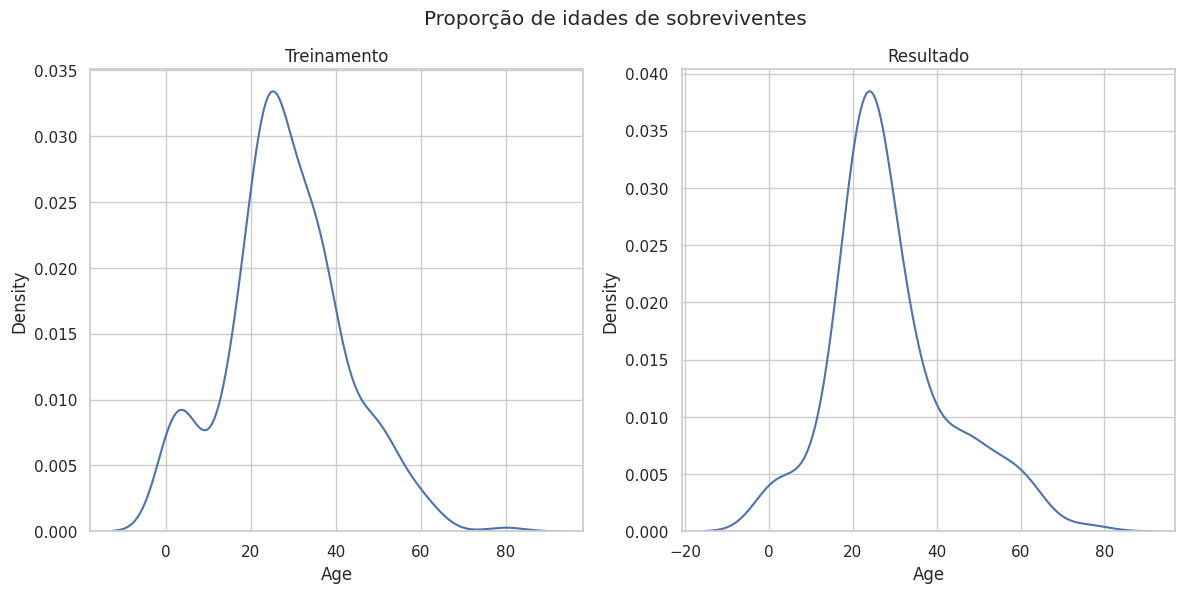

In [57]:
fig, ax = plt.subplots(1,2)
fig.set_size_inches((14,6))
fig.suptitle('Proporção de idades de sobreviventes')

fig1 = sns.kdeplot(data=df_train[df_train['Survived'] == 1], x='Age', ax=ax[0])
fig1.set_title('Treinamento')

fig2 = sns.kdeplot(data=df_result[df_result['Survived'] == 1], x='Age', ax=ax[1])
fig2.set_title('Resultado')

plt.show()

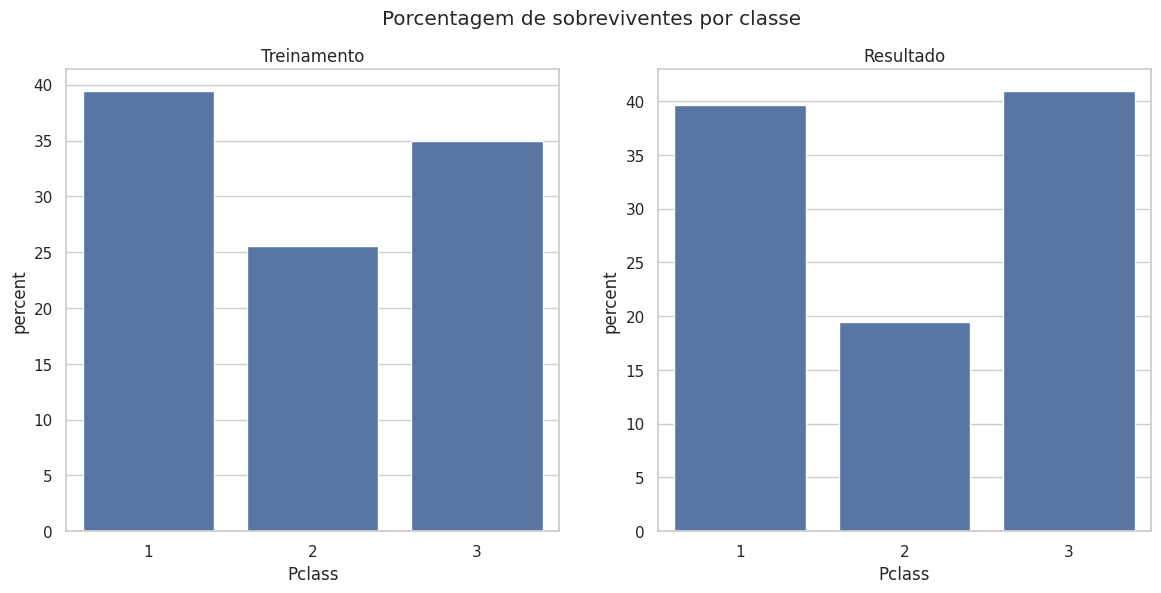

In [58]:
fig, ax = plt.subplots(1,2)
fig.set_size_inches((14,6))
fig.suptitle('Porcentagem de sobreviventes por classe')

fig1 = sns.countplot(data=df_train[df_train['Survived'] == 1], x='Pclass',stat='percent', ax=ax[0])
fig1.set_title('Treinamento')

fig2 = sns.countplot(data=df_result[df_result['Survived'] == 1], x='Pclass', stat='percent', ax=ax[1])
fig2.set_title('Resultado')

plt.show()